In [1]:
# ============================================
# Tattoo Forensic Report Generator with Qwen
# Input:
#   - JSON features generated by extractor
#   - original image (crop reconstructed from bbox)
# Output:
#   - forensic report in English
# ============================================

# -----------------------------
# Install dependencies
# -----------------------------
!pip install -q transformers accelerate qwen-vl-utils pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 24.5 MB/s eta 0:00:00


In [2]:
# -----------------------------
# Imports
# -----------------------------
import os
import json
import cv2
import torch
from PIL import Image
from google.colab import drive
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info


drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# -----------------------------
# Paths
# -----------------------------
BASE = "/content/drive/MyDrive/HDA-IWBF-2023/synthetic-tattoo-images"
IMAGE_DIR = os.path.join(BASE, "JPGImages")
JSON_DIR  = os.path.join(BASE, "debug_feature_json")
OUT_DIR   = os.path.join(BASE, "forensic_reports_qwen")
os.makedirs(OUT_DIR, exist_ok=True)

In [4]:
# -----------------------------
# Model loading
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(MODEL_ID)

print("Model loaded correctly.")

Device: cuda
GPU: Tesla T4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model loaded correctly.


In [5]:
# -----------------------------
# Helpers
# -----------------------------
def read_json(path: str):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def read_image_bgr(path: str):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return img

def expand_bbox(x, y, w, h, img_shape, margin_ratio=0.08):
    H, W = img_shape[:2]
    mx = int(w * margin_ratio)
    my = int(h * margin_ratio)

    x0 = max(0, x - mx)
    y0 = max(0, y - my)
    x1 = min(W - 1, x + w - 1 + mx)
    y1 = min(H - 1, y + h - 1 + my)

    return x0, y0, x1, y1

def crop_from_json_metadata(img_bgr, feat_json, margin_ratio=0.08):
    bbox = feat_json["spatial_features"]["bbox"]
    x = int(bbox["x"])
    y = int(bbox["y"])
    w = int(bbox["w"])
    h = int(bbox["h"])

    x0, y0, x1, y1 = expand_bbox(x, y, w, h, img_bgr.shape, margin_ratio=margin_ratio)
    crop_bgr = img_bgr[y0:y1+1, x0:x1+1].copy()
    return crop_bgr

def bgr_to_pil(img_bgr):
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return Image.fromarray(rgb)

In [6]:
# -----------------------------
# Prompt builder
# -----------------------------
def build_forensic_prompt(feat_json: dict) -> str:
    meta = feat_json["metadata"]
    spatial = feat_json["spatial_features"]
    shape = feat_json["shape_features"]
    appearance = feat_json["appearance_features"]

    prompt = f"""
You are a forensic tattoo description assistant.

You will receive:
1. a cropped image containing the tattoo region
2. structured spatial, morphological, and appearance features extracted from segmentation and image analysis

Your task is to produce a high-quality forensic description in English.

Important rules:
- Use both the image and the structured evidence.
- Be conservative and evidence-based.
- Describe only visible properties.
- Do not infer identity, ethnicity, religion, nationality, gang affiliation, symbolism, personality, or personal history.
- Do not invent meaning.
- If something is uncertain, say so explicitly.
- Prioritize accuracy, clarity, and forensic usefulness.

Structured evidence:

[Metadata]
- filename: {meta["filename"]}
- image size: {meta["image_width"]} x {meta["image_height"]}

[Spatial Features]
- tattoo area in pixels: {spatial["tattoo_area_px"]}
- visible skin area in pixels: {spatial["skin_area_px"]}
- tattoo area fraction of full image: {spatial["tattoo_area_frac_img"]:.4f}
- tattoo area fraction over visible skin: {spatial["tattoo_over_skin_frac"]:.4f}
- bounding box: x={spatial["bbox"]["x"]}, y={spatial["bbox"]["y"]}, w={spatial["bbox"]["w"]}, h={spatial["bbox"]["h"]}
- bounding box aspect ratio: {spatial["bbox_aspect_ratio"]:.4f}
- normalized center: x={spatial["position"]["x_norm"]:.4f}, y={spatial["position"]["y_norm"]:.4f}
- approximate position label: {spatial["position"]["label"]}

[Shape Features]
- raw connected components: {shape["num_components_raw"]}
- large connected components: {shape["num_components_large"]}
- perimeter: {shape["perimeter"]:.4f}
- circularity: {shape["circularity"]:.4f}
- solidity: {shape["solidity"]:.4f}
- ellipse major axis: {shape["ellipse_major_axis"]:.4f}
- ellipse minor axis: {shape["ellipse_minor_axis"]:.4f}
- elongation: {shape["elongation"]:.4f}
- orientation in degrees: {shape["orientation_deg"]:.4f}

[Appearance Features]
- tattoo grayscale mean: {appearance["tattoo_gray_mean"]:.4f}
- tattoo grayscale std: {appearance["tattoo_gray_std"]:.4f}
- skin grayscale mean: {appearance["skin_gray_mean"]:.4f}
- skin grayscale std: {appearance["skin_gray_std"]:.4f}
- skin minus tattoo grayscale contrast: {appearance["contrast_skin_minus_tattoo"]:.4f}
- Cohen's d contrast effect size: {appearance["cohens_d"]:.4f}
- crop grayscale mean: {appearance["crop_gray_mean"]:.4f}
- crop grayscale std: {appearance["crop_gray_std"]:.4f}
- global edge density in crop: {appearance["edge_density_crop"]:.4f}
- global entropy in crop: {appearance["entropy_crop"]:.4f}

Return exactly the following sections:

[Observed Description]
Write 4-6 sentences describing the tattoo's visible appearance, including apparent motif, composition, approximate position on the body region shown, overall shape, and general visual organization.

[Feature-Based Interpretation]
Write 4-6 sentences explaining how the structured spatial and shape features support the description. Refer to size, position, fragmentation, elongation, compactness, and contrast in plain forensic language.

[Visual Assessment]
Write 3-5 sentences about visible visual characteristics inferred mainly from the image, such as apparent color behavior, line-based vs filled appearance, detail level, and stylistic impression, while remaining conservative.

[Forensic Relevance]
Write 2-4 sentences explaining why this tattoo could be useful as a soft biometric cue in a forensic context.

[Limitations and Uncertainty]
Write 2-4 sentences describing limitations, ambiguities, and what cannot be reliably concluded from the image and structured features alone.
""".strip()

    return prompt

In [24]:
# -----------------------------
# Inference
# -----------------------------
def generate_report_qwen(crop_pil: Image.Image, prompt: str, max_new_tokens=500):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": crop_pil},
                {"type": "text", "text": prompt},
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )

    inputs = inputs.to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]

    response = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    return response

In [25]:
# -----------------------------
# Save outputs
# -----------------------------
def save_report_outputs(base_name: str, feat_json: dict, prompt: str, report: str):
    txt_path = os.path.join(OUT_DIR, f"{base_name}_report.txt")
    json_path = os.path.join(OUT_DIR, f"{base_name}_report.json")

    with open(txt_path, "w", encoding="utf-8") as f:
        f.write(report)

    payload = {
        "source_features_file": f"{base_name}.json",
        "metadata": feat_json["metadata"],
        "input_features": feat_json,
        "prompt": prompt,
        "report": report,
    }

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)

    return txt_path, json_path

In [28]:
# -----------------------------
# Run one example
# -----------------------------
JSON_FILENAME = None
# Example:
# JSON_FILENAME = "01_14_1.37_2593.json"

if JSON_FILENAME is None:
    json_files = sorted([f for f in os.listdir(JSON_DIR) if f.lower().endswith(".json")])
    if not json_files:
        raise RuntimeError("No JSON files found in JSON_DIR.")
    JSON_FILENAME = json_files[3]

json_path = os.path.join(JSON_DIR, JSON_FILENAME)
feat_json = read_json(json_path)

image_filename = feat_json["metadata"]["filename"]
image_path = os.path.join(IMAGE_DIR, image_filename)

print("JSON file:", json_path)
print("Image file:", image_path)

img_bgr = read_image_bgr(image_path)
crop_bgr = crop_from_json_metadata(img_bgr, feat_json, margin_ratio=0.08)
crop_pil = bgr_to_pil(crop_bgr)

prompt = build_forensic_prompt(feat_json)
report = generate_report_qwen(crop_pil, prompt, max_new_tokens=500)

JSON file: /content/drive/MyDrive/HDA-IWBF-2023/synthetic-tattoo-images/debug_feature_json/0e5ecf98835cbd0dddd1b45c788005c3_transparent_golden_149_1.41_2228.json
Image file: /content/drive/MyDrive/HDA-IWBF-2023/synthetic-tattoo-images/JPGImages/0e5ecf98835cbd0dddd1b45c788005c3_transparent_golden_149_1.41_2228.jpg


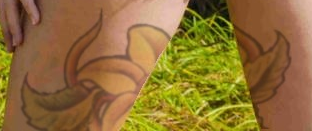


================ PROMPT ================

You are a forensic tattoo description assistant.

All responses must be written strictly in English.
Never use any other language.

You will receive:
1. a cropped image containing the tattoo region
2. structured spatial, morphological, and appearance features extracted from segmentation and image analysis

Your task is to produce a high-quality forensic description.

STRICT RULES:
- Describe ONLY what is directly visible.
- Do NOT infer emotions, personality, intention, symbolism, or meaning.
- Do NOT describe facial expression in subjective terms.
- Do NOT infer identity, ethnicity, nationality, religion, gang affiliation, or personal history.
- Do NOT invent details that are not clearly supported by the image.
- If something is uncertain, express uncertainty cautiously.
- Use a neutral, precise, and forensic tone.
- Do NOT mention raw numeric feature values.
- Instead, translate the structured evidence into qualitative forensic language.
- D

In [29]:
# -----------------------------
# Show results
# -----------------------------
display(crop_pil)

print("\n================ PROMPT ================\n")
print(prompt[:5000])

print("\n================ FORENSIC REPORT ================\n")
print(report)

base_name = os.path.splitext(JSON_FILENAME)[0]
txt_path, out_json_path = save_report_outputs(base_name, feat_json, prompt, report)

print("\nSaved report TXT:", txt_path)
print("Saved report JSON:", out_json_path)

Es buen report, pero dice cosas como que el tatuaje está en el brazo (está en la pierna). No queremos que diga la parte del cuerpo sino la localización en la imagen. Además habla de la expresión del rostro (tatuaje de una cara), lo que considero algo subjetivo, y no quiero que se hagan este tipo de observaciones. También menciona valores numéricos de la extracción de características en vez de decir lo que significa. Modificamos un poco el prompt.

In [23]:
def build_forensic_prompt(feat_json: dict) -> str:
    meta = feat_json["metadata"]
    spatial = feat_json["spatial_features"]
    shape = feat_json["shape_features"]
    appearance = feat_json["appearance_features"]

    # -----------------------------
    # Qualitative interpretations
    # -----------------------------
    area_frac_img = spatial["tattoo_area_frac_img"]
    over_skin = spatial["tattoo_over_skin_frac"]
    bbox_aspect = spatial["bbox_aspect_ratio"]
    pos_label = spatial["position"]["label"]

    num_large = shape["num_components_large"]
    circularity = shape["circularity"]
    solidity = shape["solidity"]
    elongation = shape["elongation"]

    contrast = appearance["contrast_skin_minus_tattoo"]
    edge_density = appearance["edge_density_crop"]
    entropy = appearance["entropy_crop"]

    # Size in image
    if area_frac_img < 0.01:
        size_img_desc = "very small relative to the full image"
    elif area_frac_img < 0.05:
        size_img_desc = "small relative to the full image"
    elif area_frac_img < 0.12:
        size_img_desc = "moderate in size relative to the full image"
    else:
        size_img_desc = "large relative to the full image"

    # Size over visible skin
    if over_skin < 0.05:
        size_skin_desc = "occupies a small portion of the visible skin region"
    elif over_skin < 0.15:
        size_skin_desc = "occupies a moderate portion of the visible skin region"
    else:
        size_skin_desc = "occupies a substantial portion of the visible skin region"

    # Position
    position_desc_map = {
        "center": "near the center of the visible skin region in the image",
        "center-left": "slightly toward the left side of the visible skin region",
        "center-right": "slightly toward the right side of the visible skin region",
        "top-center": "toward the upper central area of the visible skin region",
        "bottom-center": "toward the lower central area of the visible skin region",
        "top-left": "toward the upper-left area of the visible skin region",
        "top-right": "toward the upper-right area of the visible skin region",
        "bottom-left": "toward the lower-left area of the visible skin region",
        "bottom-right": "toward the lower-right area of the visible skin region",
        "none": "in an unspecified area of the visible skin region",
    }
    position_desc = position_desc_map.get(pos_label, "within the visible skin region")

    # Aspect ratio / global shape
    if bbox_aspect < 0.70:
        bbox_desc = "predominantly vertical and taller than wide"
    elif bbox_aspect > 1.40:
        bbox_desc = "predominantly horizontal and wider than tall"
    else:
        bbox_desc = "roughly balanced in width and height"

    # Components
    if num_large <= 1:
        comp_desc = "appears as a single main connected region"
    elif num_large == 2:
        comp_desc = "appears to contain two main connected regions"
    elif num_large <= 4:
        comp_desc = "appears to contain several connected regions"
    else:
        comp_desc = "appears noticeably fragmented into multiple connected regions"

    # Circularity
    if circularity < 0.20:
        circularity_desc = "highly irregular rather than rounded"
    elif circularity < 0.50:
        circularity_desc = "irregular in outline"
    else:
        circularity_desc = "relatively rounded or compact in outline"

    # Solidity
    if solidity < 0.50:
        solidity_desc = "visually non-compact, with a dispersed or open outline"
    elif solidity < 0.80:
        solidity_desc = "moderately compact"
    else:
        solidity_desc = "visually compact and coherent"

    # Elongation
    if elongation < 1.3:
        elongation_desc = "not strongly elongated"
    elif elongation < 2.0:
        elongation_desc = "moderately elongated"
    else:
        elongation_desc = "clearly elongated"

    # Contrast
    if contrast is None:
        contrast_desc = "contrast with surrounding skin is not available"
    elif contrast < 10:
        contrast_desc = "shows low contrast against the surrounding skin"
    elif contrast < 25:
        contrast_desc = "shows moderate contrast against the surrounding skin"
    else:
        contrast_desc = "shows strong contrast against the surrounding skin"

    # Edge density
    if edge_density is None:
        edge_desc = "edge-based visual complexity is not available"
    elif edge_density < 0.03:
        edge_desc = "has relatively low edge density and limited fine contour activity"
    elif edge_density < 0.08:
        edge_desc = "has moderate edge density"
    else:
        edge_desc = "has high edge density and strong contour activity"

    # Entropy
    if entropy is None:
        entropy_desc = "global tonal complexity is not available"
    elif entropy < 5.0:
        entropy_desc = "shows relatively low tonal complexity"
    elif entropy < 6.5:
        entropy_desc = "shows moderate tonal complexity"
    else:
        entropy_desc = "shows high tonal complexity"

    prompt = f"""
You are a forensic tattoo description assistant.

All responses must be written strictly in English.
Never use any other language.

You will receive:
1. a cropped image containing the tattoo region
2. structured spatial, morphological, and appearance features extracted from segmentation and image analysis

Your task is to produce a high-quality forensic description.

STRICT RULES:
- Describe ONLY what is directly visible.
- Do NOT infer emotions, personality, intention, symbolism, or meaning.
- Do NOT describe facial expression in subjective terms.
- Do NOT infer identity, ethnicity, nationality, religion, gang affiliation, or personal history.
- Do NOT invent details that are not clearly supported by the image.
- If something is uncertain, express uncertainty cautiously.
- Use a neutral, precise, and forensic tone.
- Do NOT mention raw numeric feature values.
- Instead, translate the structured evidence into qualitative forensic language.
- Do not mention body part at all, just mention where is located in the image.

Structured evidence already interpreted in qualitative terms:

[Metadata]
- Source image filename: {meta["filename"]}

[Spatial Interpretation]
- The tattoo is {size_img_desc}.
- It {size_skin_desc}.
- Its position is best described as {position_desc}.
- Its overall bounding-box geometry is {bbox_desc}.

[Shape Interpretation]
- The tattoo {comp_desc}.
- Its outer contour is {circularity_desc}.
- Its overall structure is {solidity_desc}.
- Its global shape is {elongation_desc}.

[Appearance Interpretation]
- It {contrast_desc}.
- It {edge_desc}.
- It {entropy_desc}.

Return exactly the following sections:

[Observed Description]
Write 4-6 sentences.
Describe only visible elements such as:
- apparent motif or subject
- visible composition
- approximate position in the image
- overall visible structure
Do not mention body part unless it is explicitly visible and certain.
Do not use emotional or subjective wording.

[Feature-Based Interpretation]
Write 4-6 sentences.
Explain how the structured evidence supports the description, but only in qualitative language.
Do not mention raw measurements or numeric values.

[Visual Assessment]
Write 3-5 sentences.
Describe visible visual properties such as:
- apparent color behavior
- detail level
- shading vs line-based appearance
- compact vs fragmented visual impression
Avoid subjective wording and avoid unsupported claims.

[Forensic Relevance]
Write 2-4 sentences.
Explain why this tattoo could be useful as a soft biometric cue in a forensic context, based on visible distinctiveness, structure, size, and composition.

[Limitations and Uncertainty]
Write 2-4 sentences, just if there are any uncertainties, if not, don't do this part.
State only relevant limitations.
Do not infer meaning, identity, or symbolism.
""".strip()

    return prompt